# Test inference notebook\n
\n
This notebook validates that inference is really running: it loads models, runs prediction on the latest scraped image, draws bounding boxes, and saves an annotated output.

In [1]:
from pathlib import Path
from datetime import datetime
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
# Project paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIRS = [
    PROJECT_ROOT / 'data' / 'raw' / 'webcam_cardiff_snapshots',
    PROJECT_ROOT / 'data' / 'raw' / 'webcam_murcia_snapshots',
    PROJECT_ROOT / 'data' / 'raw' / 'webcam_lapalma_snapshots',
]
MODEL_PERSON_PATH = PROJECT_ROOT / 'models' / 'best_people.pt'
MODEL_CAR_PATH = PROJECT_ROOT / 'models' / 'best_car.pt'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'final' / 'image_annoted'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('MODEL_PERSON_PATH exists:', MODEL_PERSON_PATH.exists())
print('MODEL_CAR_PATH exists:', MODEL_CAR_PATH.exists())

PROJECT_ROOT: /mnt/c/Users/tanjo/projetcs/place_publique
MODEL_PERSON_PATH exists: True
MODEL_CAR_PATH exists: True


In [3]:
def resolve_class_ids(model, keywords):
    ids = []
    for class_id, class_name in model.names.items():
        name = str(class_name).lower().strip()
        if any(k in name for k in keywords):
            ids.append(int(class_id))
    ids = sorted(set(ids))
    return ids if ids else None

def find_latest_raw_image(raw_dirs):
    candidates = []
    for d in raw_dirs:
        if d.exists():
            for p in d.glob('*'):
                if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.webp'} and p.is_file():
                    candidates.append(p)
    if not candidates:
        raise FileNotFoundError('No raw webcam image found in data/raw/webcam_*_snapshots')
    return max(candidates, key=lambda p: p.stat().st_mtime)

In [ ]:
# Load models
model_person = YOLO(str(MODEL_PERSON_PATH))
model_car = YOLO(str(MODEL_CAR_PATH))

person_classes = resolve_class_ids(model_person, ['people', 'pedestrian', 'person'])
car_classes = resolve_class_ids(model_car, ['car', 'cars', 'vehicle', 'truck', 'bus'])

print('person_classes:', person_classes)
print('car_classes:', car_classes)

person_classes: [0]
car_classes: [0, 1]


In [7]:
# Pick latest scraped image
image_path = find_latest_raw_image(RAW_DIRS)
print('Input image:', image_path)

img = cv2.imread(str(image_path))
if img is None:
    raise RuntimeError(f'Cannot read image: {image_path}')

detections = []
detection_count = {'person': 0, 'car': 0}

# Person model inference
res_person = model_person.predict(source=str(image_path), classes=person_classes, conf=0.25, save=False, verbose=False)[0]
if res_person.boxes is not None:
    for box in res_person.boxes:
        conf = round(float(box.conf[0]), 2)
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        cv2.rectangle(img, (x1, y1), (x2, y2), (219, 142, 0), 2)
        cv2.putText(img, f'person {conf}', (x1, max(10, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (219, 142, 0), 1)
        detections.append({'class': 'person', 'confidence': conf})
        detection_count['person'] += 1

# Car model inference
res_car = model_car.predict(source=str(image_path), classes=car_classes, conf=0.25, save=False, verbose=False)[0]
if res_car.boxes is not None:
    for box in res_car.boxes:
        conf = round(float(box.conf[0]), 2)
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 220), 2)
        cv2.putText(img, f'car {conf}', (x1, max(10, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 220), 1)
        detections.append({'class': 'car', 'confidence': conf})
        detection_count['car'] += 1

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out_path = OUTPUT_DIR / f'notebook_inference_{ts}.png'
ok = cv2.imwrite(str(out_path), img)
if not ok:
    raise RuntimeError(f'Failed to write output image: {out_path}')

print('Output image:', out_path)
print('Detections total:', len(detections))
print('Detections by class:', detection_count)

Input image: /mnt/c/Users/tanjo/projetcs/place_publique/data/raw/webcam_lapalma_snapshots/lapalma_20260315_162730.png
Output image: /mnt/c/Users/tanjo/projetcs/place_publique/data/final/image_annoted/notebook_inference_20260315_193214.png
Detections total: 0
Detections by class: {'person': 0, 'car': 0}


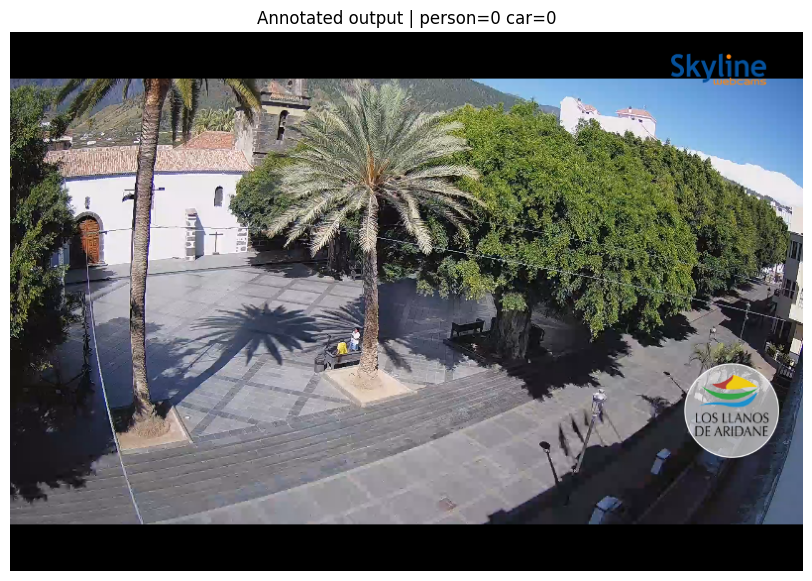

In [8]:
# Display annotated output
img_rgb = cv2.cvtColor(cv2.imread(str(out_path)), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Annotated output | person={detection_count["person"]} car={detection_count["car"]}')
plt.show()